# Event 03 — 화이자 백신 90% 효과 발표 (2020-11-09)
## 스토리텔링 차트 (Scrollytelling Stepper)

### 배경
2020년 11월 9일 장전, 화이자-바이오엔텍이 mRNA 백신 3상 임상 중간분석에서 **90% 이상의 효과**를 발표. 시장은 새 시대로 진입하며 3중 변화가 동시에 일어났다:

1. **S&P 500**: 사상 최고치 돌파
2. **공포 지수 (VIX)**: 37 → 20대 초반으로 급락
3. **성장주 (ARKK)**: 로테이션 매도 → 이후 반등 (Stay-at-home → Reopening)

### 출력
- `data/figures/e03_story/00_prologue.png` … `05_act5.png`
- `data/figures/e03_story/99_summary.png`

## 1. Imports & 경로 설정

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
PANEL_PATH = ROOT / 'data' / 'processed' / 'panel_daily.csv'
FIG_DIR    = ROOT / 'data' / 'figures' / 'e03_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT     : {ROOT}')
print(f'FIG_DIR  : {FIG_DIR}')

ROOT     : c:\Users\kimch\Desktop\project\pandemic-finance
FIG_DIR  : c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story


## 2. 데이터 로드 — 3중 자산 패널

`panel_daily.csv` 에서 SP500 · VIX · ARKK 컬럼만 추출해, 2020-10-12 ~ 2020-12-09 구간으로 잘라 쓴다.

In [2]:
panel = pd.read_csv(PANEL_PATH, index_col=0, parse_dates=True)
df = panel.loc['2020-10-12':'2020-12-09', ['SP500', 'VIX', 'ARKK']].copy()

print(f'shape: {df.shape}, {df.index.min().date()} ~ {df.index.max().date()}')
print()
print('Key dates:')
for d in ['2020-11-02', '2020-11-06', '2020-11-09', '2020-11-10', '2020-11-16', '2020-12-08']:
    dt = pd.Timestamp(d)
    if dt in df.index:
        r = df.loc[dt]
        print(f'  {d}  SP500={r.SP500:>7.2f}  VIX={r.VIX:>5.2f}  ARKK={r.ARKK:>6.2f}')
df.head(3)

shape: (43, 3), 2020-10-12 ~ 2020-12-09

Key dates:
  2020-11-02  SP500=3310.24  VIX=37.13  ARKK= 87.91
  2020-11-06  SP500=3509.44  VIX=24.86  ARKK= 98.83
  2020-11-09  SP500=3550.50  VIX=25.75  ARKK= 94.32
  2020-11-10  SP500=3545.53  VIX=24.80  ARKK= 91.74
  2020-11-16  SP500=3626.91  VIX=22.45  ARKK= 96.37
  2020-12-08  SP500=3702.25  VIX=20.68  ARKK=118.28


,SP500,VIX,ARKK
2020-10-12,3534.22,25.07,99.067703
2020-10-13,3511.93,26.07,101.487999
2020-10-14,3488.67,26.40,100.461792


## 3. 6국면 정의 — 이름·서사·핵심 주석

In [3]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 2차 유행 & 대선 공포',
        'start': '2020-10-12', 'end': '2020-11-02', 'color': '#90A4AE',
        'narrative': '미국 2차 코로나 유행과 불확실한 대선이 겹쳐 시장은 굳어 있었다. 공포 지수(VIX)는 10월 말 37까지 치솟았다.',
        'hero_annotations': [
            ('2020-10-28', 'SP500', 3271.03, '2차 유행 피크\n주간 -6.4%', (-40, -40), 'right'),
            ('2020-11-02', 'VIX',     37.13, 'VIX 37\n대선 전야 공포', (-80, 30), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — 선거 & 안도 랠리',
        'start': '2020-11-03', 'end': '2020-11-06', 'color': '#FFB74D',
        'narrative': '대선 불확실성이 걷히자 안도 랠리가 시작됐다. 공포 지수는 3거래일 만에 37 → 25로 급락.',
        'hero_annotations': [
            ('2020-11-03', 'SP500', 3369.16, '미국 대선일', (-60, 30), 'left'),
            ('2020-11-06', 'VIX',     24.86, 'VIX -33%\n(3거래일)', (15, 20), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — 화이자 쇼크',
        'start': '2020-11-09', 'end': '2020-11-09', 'color': '#43A047',
        'narrative': '11월 9일 월요일 장전 — 화이자-바이오엔텍의 백신 3상 중간분석에서 "효과 90% 이상" 발표. 시장은 새 시대로 진입했다.',
        'hero_annotations': [
            ('2020-11-09', 'SP500', 3550.50, '⭐ 화이자 90% 발표\nSP500 사상 최고', (25, 30), 'left'),
            ('2020-11-09', 'VIX',     25.75, '백신 기대감\n공포 약화', (25, 20), 'left'),
            ('2020-11-09', 'ARKK',    94.32, '성장주 첫 흔들림\n(로테이션 시작)', (25, -35), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — 로테이션 트레이드',
        'start': '2020-11-10', 'end': '2020-11-13', 'color': '#AB47BC',
        'narrative': 'Stay-at-home → Reopening. 성장주(테크·ARKK)가 팔리고 재개방주(항공·크루즈·금융)가 솟았다. SP500은 고점을 유지하며 내부만 재편됐다.',
        'hero_annotations': [
            ('2020-11-10', 'ARKK',    91.74, '로테이션 데이\nARKK -2.7%', (-70, -40), 'left'),
            ('2020-11-13', 'SP500', 3585.15, '신고가 유지\n(내부 재편)', (15, -35), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — 모더나 확증',
        'start': '2020-11-16', 'end': '2020-11-18', 'color': '#26A69A',
        'narrative': '모더나 94.5%, 화이자 업데이트 95%. 두 번째·세 번째 확증으로 백신 서사는 돌이킬 수 없게 되었다. 공포 지수는 20대 초반으로 안착.',
        'hero_annotations': [
            ('2020-11-16', 'SP500', 3626.91, '모더나 94.5%\n발표', (-40, 25), 'left'),
            ('2020-11-18', 'VIX',     23.84, '화이자 → 95%\n공포 정상화', (15, 15), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — 랠리 지속',
        'start': '2020-11-19', 'end': '2020-12-09', 'color': '#66BB6A',
        'narrative': 'FDA 긴급승인(12/11)을 앞두고 랠리가 이어졌다. 일시 위축됐던 성장주도 반등 — ARKK는 11/10 저점 대비 +27%로 복귀.',
        'hero_annotations': [
            ('2020-12-08', 'SP500', 3702.25, 'SP500 사상 최고\n3,702', (-90, 25), 'left'),
            ('2020-12-09', 'ARKK',   116.16, 'ARKK 반등 +27%\n(11/10 저점 대비)', (-130, -35), 'left'),
        ],
    },
]

pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 2차 유행 & 대선 공포,2020-10-12,2020-11-02,#90A4AE,미국 2차 코로나 유행과 불확실한 대선이 겹쳐 시장은 굳어 있었다. 공포 지수(VI...
1,act1,Act 1 — 선거 & 안도 랠리,2020-11-03,2020-11-06,#FFB74D,대선 불확실성이 걷히자 안도 랠리가 시작됐다. 공포 지수는 3거래일 만에 37 → ...
2,act2,Act 2 — 화이자 쇼크,2020-11-09,2020-11-09,#43A047,"11월 9일 월요일 장전 — 화이자-바이오엔텍의 백신 3상 중간분석에서 ""효과 90..."
3,act3,Act 3 — 로테이션 트레이드,2020-11-10,2020-11-13,#AB47BC,Stay-at-home → Reopening. 성장주(테크·ARKK)가 팔리고 재개...
4,act4,Act 4 — 모더나 확증,2020-11-16,2020-11-18,#26A69A,"모더나 94.5%, 화이자 업데이트 95%. 두 번째·세 번째 확증으로 백신 서사는..."
5,act5,Act 5 — 랠리 지속,2020-11-19,2020-12-09,#66BB6A,FDA 긴급승인(12/11)을 앞두고 랠리가 이어졌다. 일시 위축됐던 성장주도 반등...


## 4. 공통 상수 & 헬퍼 함수

In [4]:
XLIM       = (pd.Timestamp('2020-10-12'), pd.Timestamp('2020-12-09'))
YLIM_SP    = (3200, 3760)
YLIM_VIX   = (18, 42)
YLIM_ARKK  = (80, 122)
DIM_COLOR  = '#D0D0D0'

LABELS = {
    'SP500': 'S&P 500 주가지수',
    'VIX':   '시장 공포 지수 (VIX)',
    'ARKK':  '성장주 ETF (ARKK, $)',
}


def plot_panel(ax, series, active_color, ylabel, visible_end, phase, fill=False):
    """디밍된 전체선 + 활성 구간 오버레이."""
    mask_v = series.index <= visible_end
    xv, yv = series.index[mask_v], series[mask_v]

    # 배경 디밍
    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.8, zorder=2)
    if fill:
        ax.fill_between(xv, yv, YLIM_VIX[0], color=DIM_COLOR, alpha=0.2, zorder=1)

    # 활성 오버레이
    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    mask_a = (xv >= ps) & (xv <= pe)
    if mask_a.any():
        ax.plot(xv[mask_a], yv[mask_a], color=active_color, lw=3.2, zorder=5,
                marker='o', markersize=6, markerfacecolor=active_color,
                markeredgecolor='white', markeredgewidth=1.3)
        if fill:
            ax.fill_between(xv[mask_a], yv[mask_a], YLIM_VIX[0],
                            color=active_color, alpha=0.3, zorder=3)

    ax.set_ylabel(ylabel, fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx, show_future=False):
    phase = phases[idx]
    phase_end = pd.Timestamp(phase['end'])
    visible_end = XLIM[1] if show_future else phase_end + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.35, 1.4, 1.1, 1.1], hspace=0.18)
    ax_rib  = fig.add_subplot(gs[0])
    ax_sp   = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_vix  = fig.add_subplot(gs[2], sharex=ax_rib)
    ax_arkk = fig.add_subplot(gs[3], sharex=ax_rib)

    # Ribbon
    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start'])
        e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center',
                    fontsize=10 if active else 8.5,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    # Title & narrative
    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935, phase['narrative'],
             ha='center', va='top', fontsize=11.5, color='#333',
             style='italic', wrap=True)

    # 세 패널
    plot_panel(ax_sp,   df['SP500'], phase['color'], LABELS['SP500'], visible_end, phase)
    plot_panel(ax_vix,  df['VIX'],   phase['color'], LABELS['VIX'],   visible_end, phase, fill=True)
    plot_panel(ax_arkk, df['ARKK'],  phase['color'], LABELS['ARKK'],  visible_end, phase)

    ax_sp.set_ylim(YLIM_SP)
    ax_vix.set_ylim(YLIM_VIX)
    ax_arkk.set_ylim(YLIM_ARKK)

    # 11/9 수직선 (Act 2 이후)
    pfizer = pd.Timestamp('2020-11-09')
    if pfizer <= visible_end:
        alpha = 0.75 if idx >= 2 else 0.2
        for ax in (ax_sp, ax_vix, ax_arkk):
            ax.axvline(pfizer, color='#2E7D32', linestyle=':',
                       lw=1.6, alpha=alpha, zorder=2)

    # Hero annotations
    axmap = {'SP500': ax_sp, 'VIX': ax_vix, 'ARKK': ax_arkk}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date)
        c = phase['color']
        ax.scatter([d], [y], s=85, color=c, zorder=6,
                   edgecolors='white', lw=1.8)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white',
                              ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    # X축 (최하단만)
    ax_arkk.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_arkk.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_arkk.tick_params(axis='x', labelsize=9)
    ax_arkk.set_xlabel('2020년', fontsize=10.5)
    for ax in (ax_rib, ax_sp, ax_vix):
        plt.setp(ax.get_xticklabels(), visible=False)

    # Footer
    fig.text(0.5, 0.01,
             'Data: FRED · Yahoo (SP500 · VIX · ARKK)   ·   회색 = 전체 기간 참고   ·   진한 색 = 현재 국면',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 5. 스토리 프레임 6장 순서대로 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_6688\3710166884.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


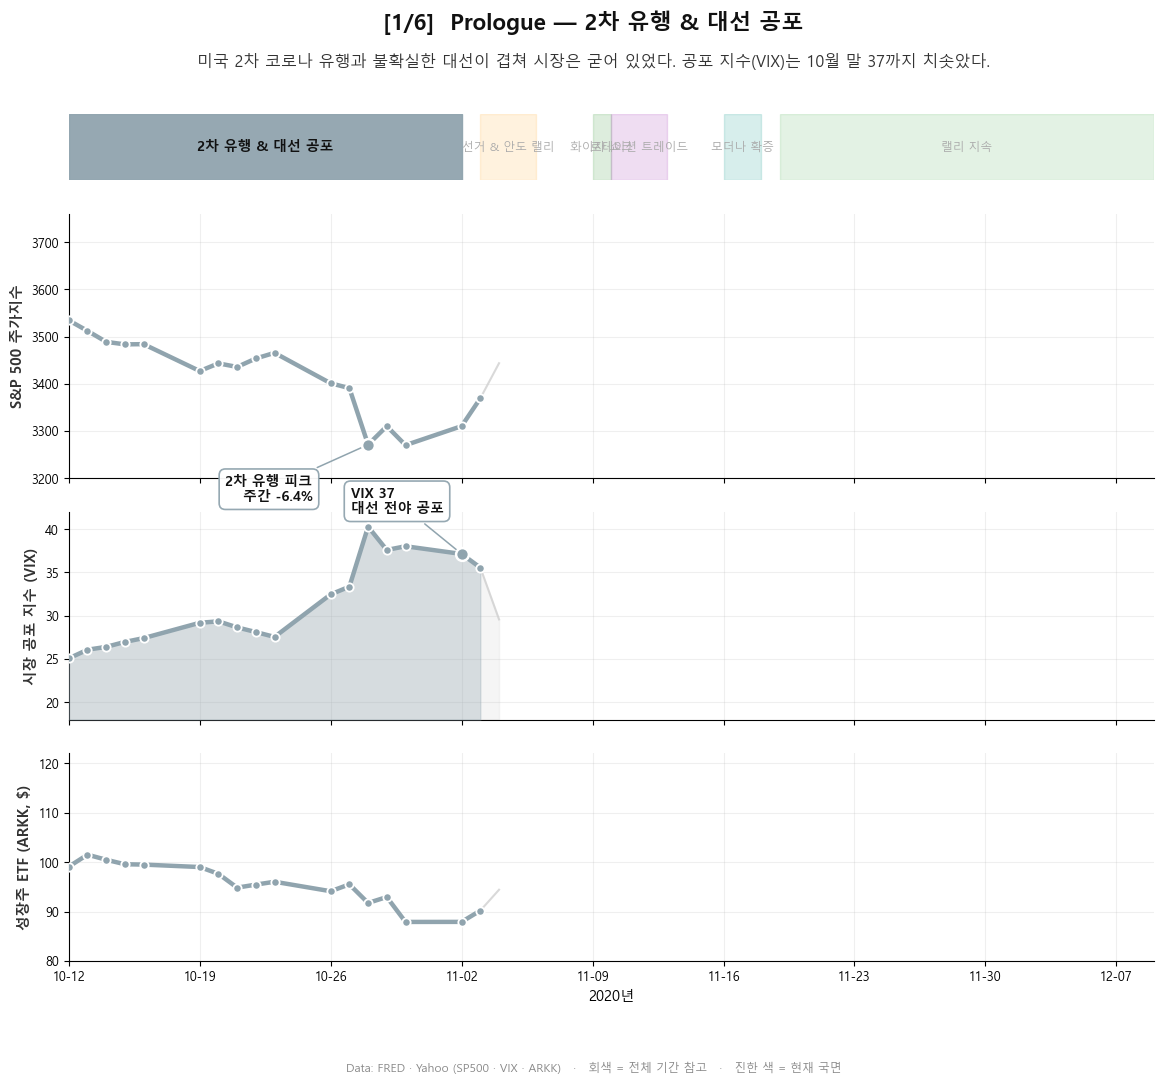

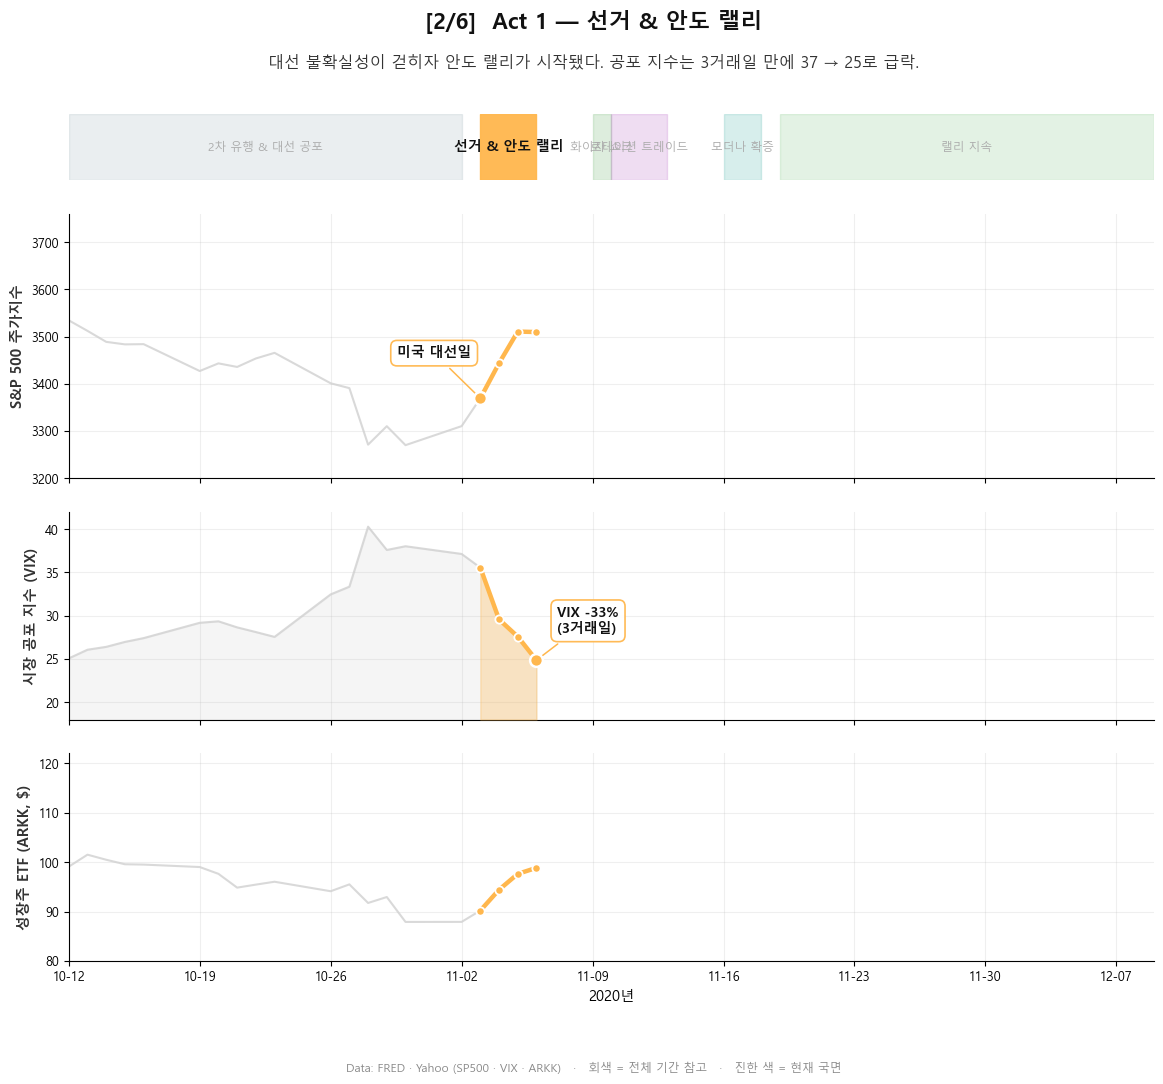

C:\Users\kimch\AppData\Local\Temp\ipykernel_6688\3710166884.py:129: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


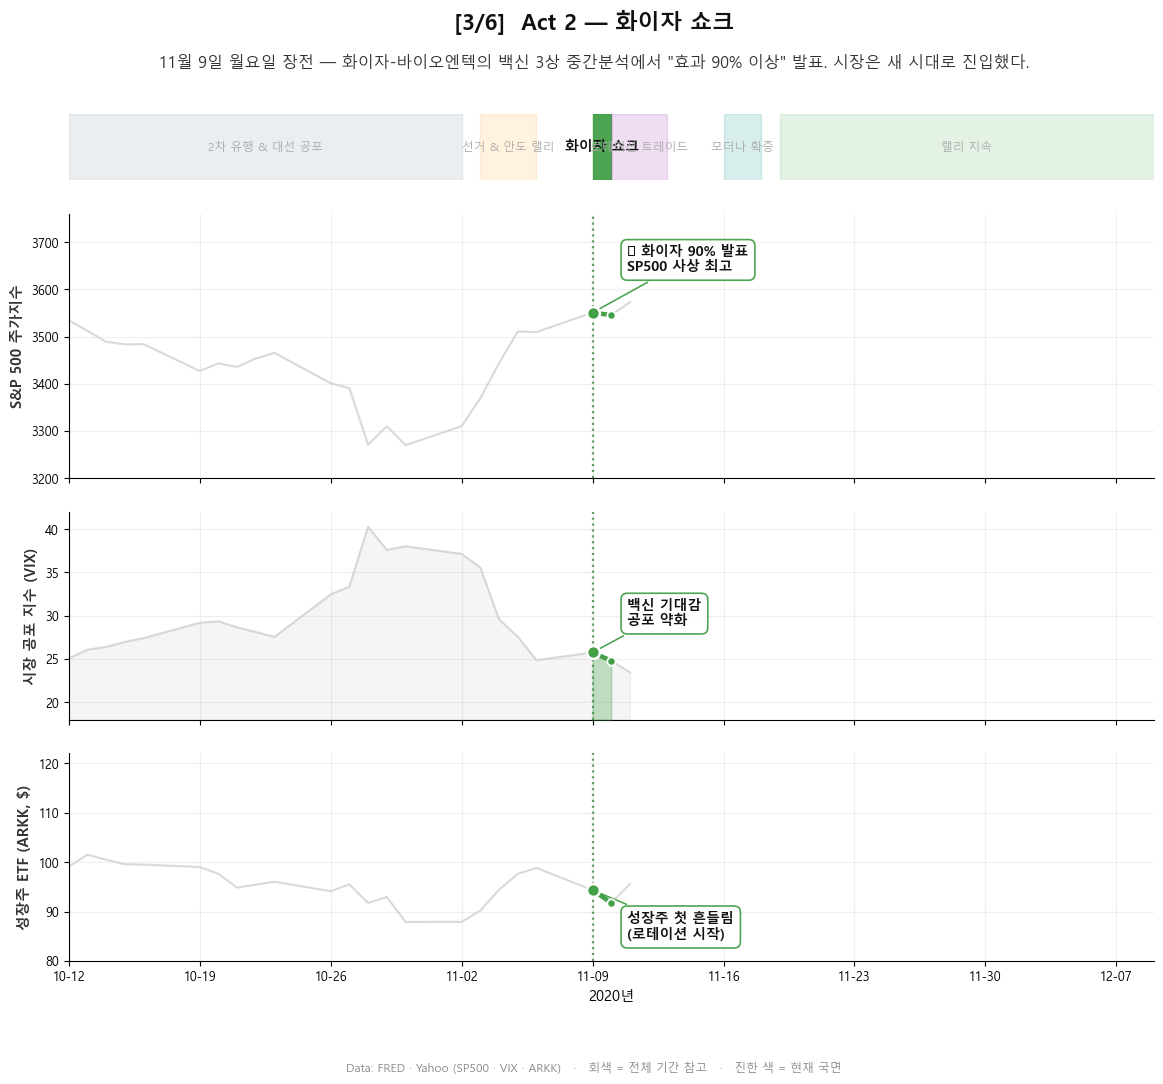

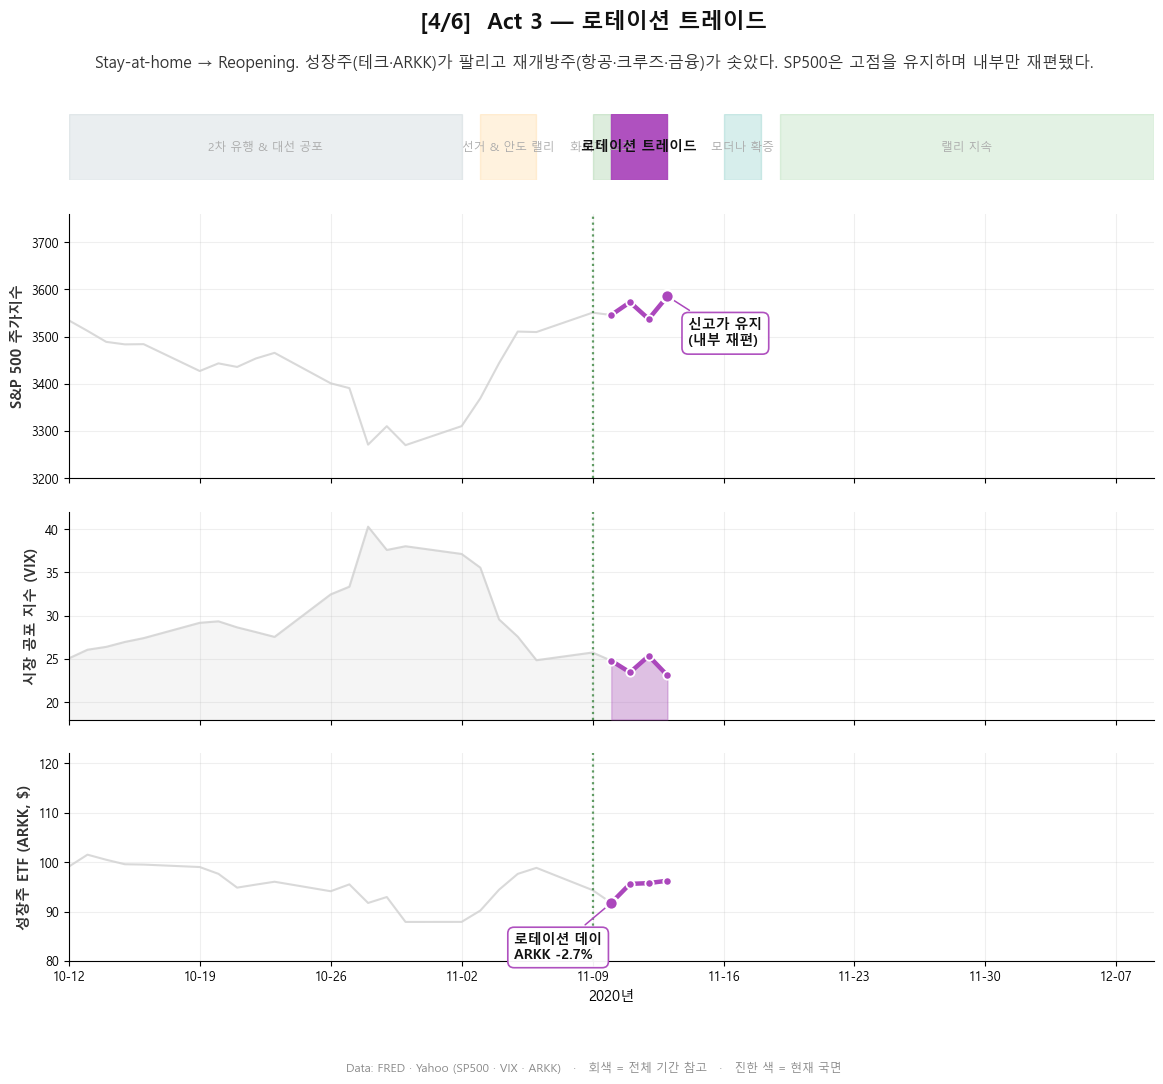

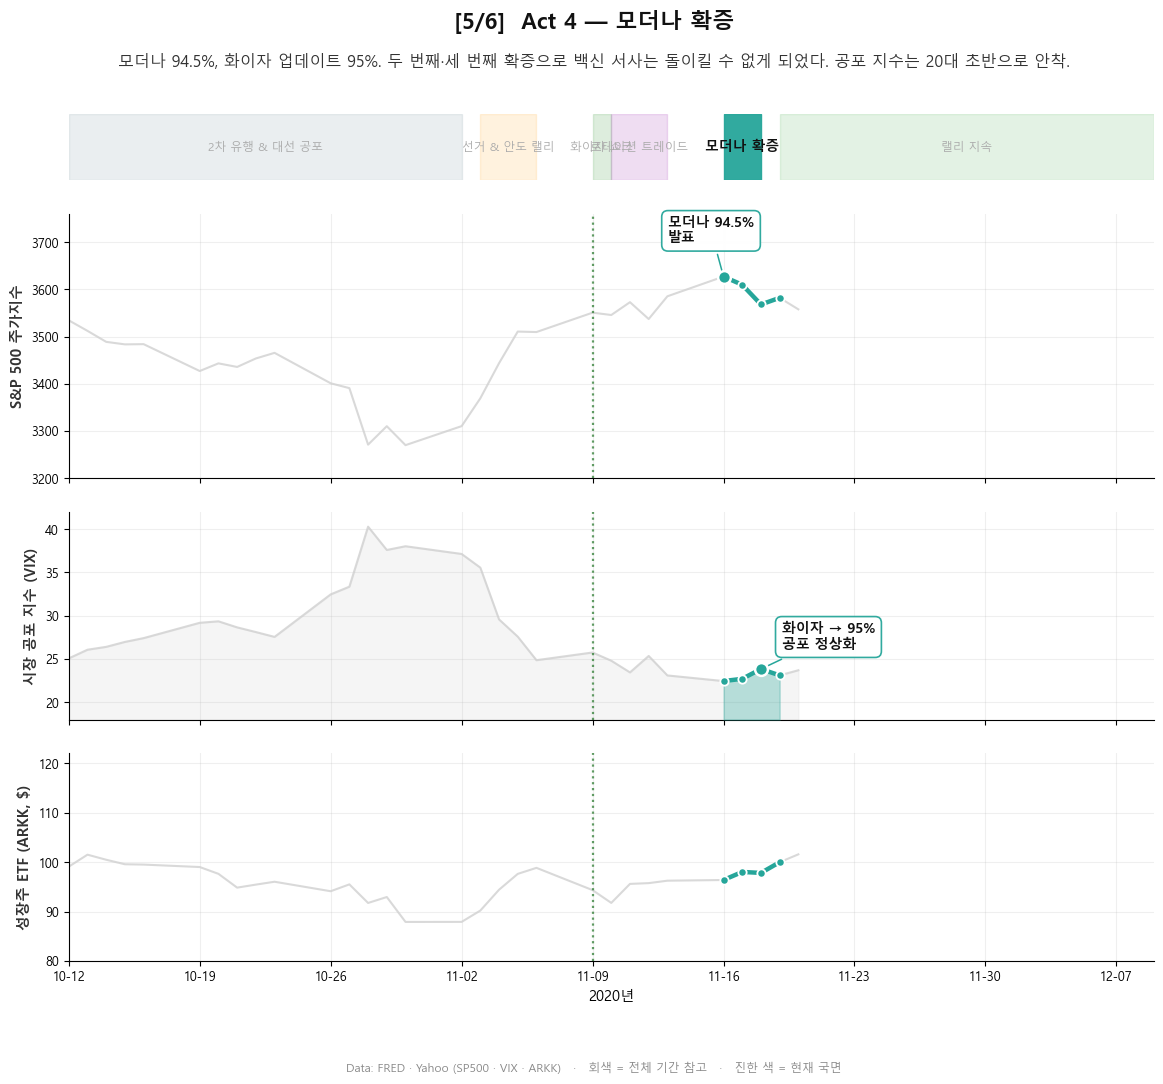

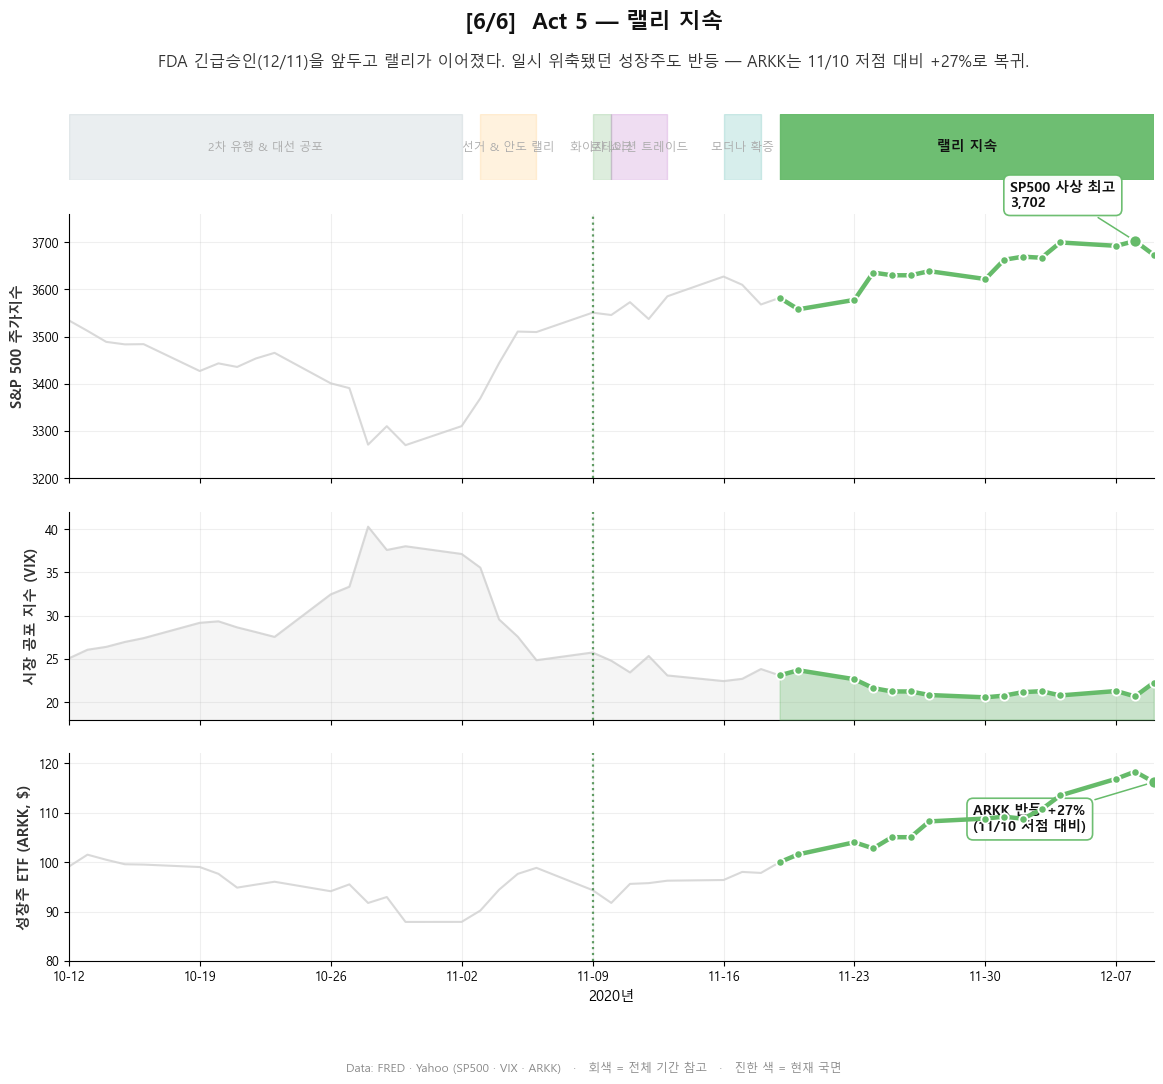


[OK] 저장된 프레임:
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\05_act5.png


In [5]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()

print('\n[OK] 저장된 프레임:')
for p in saved:
    print(f'  - {p}')

## 6. 종합 프레임 — 모든 국면을 한 장으로

C:\Users\kimch\AppData\Local\Temp\ipykernel_6688\869961550.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])
C:\Users\kimch\AppData\Local\Temp\ipykernel_6688\869961550.py:91: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')


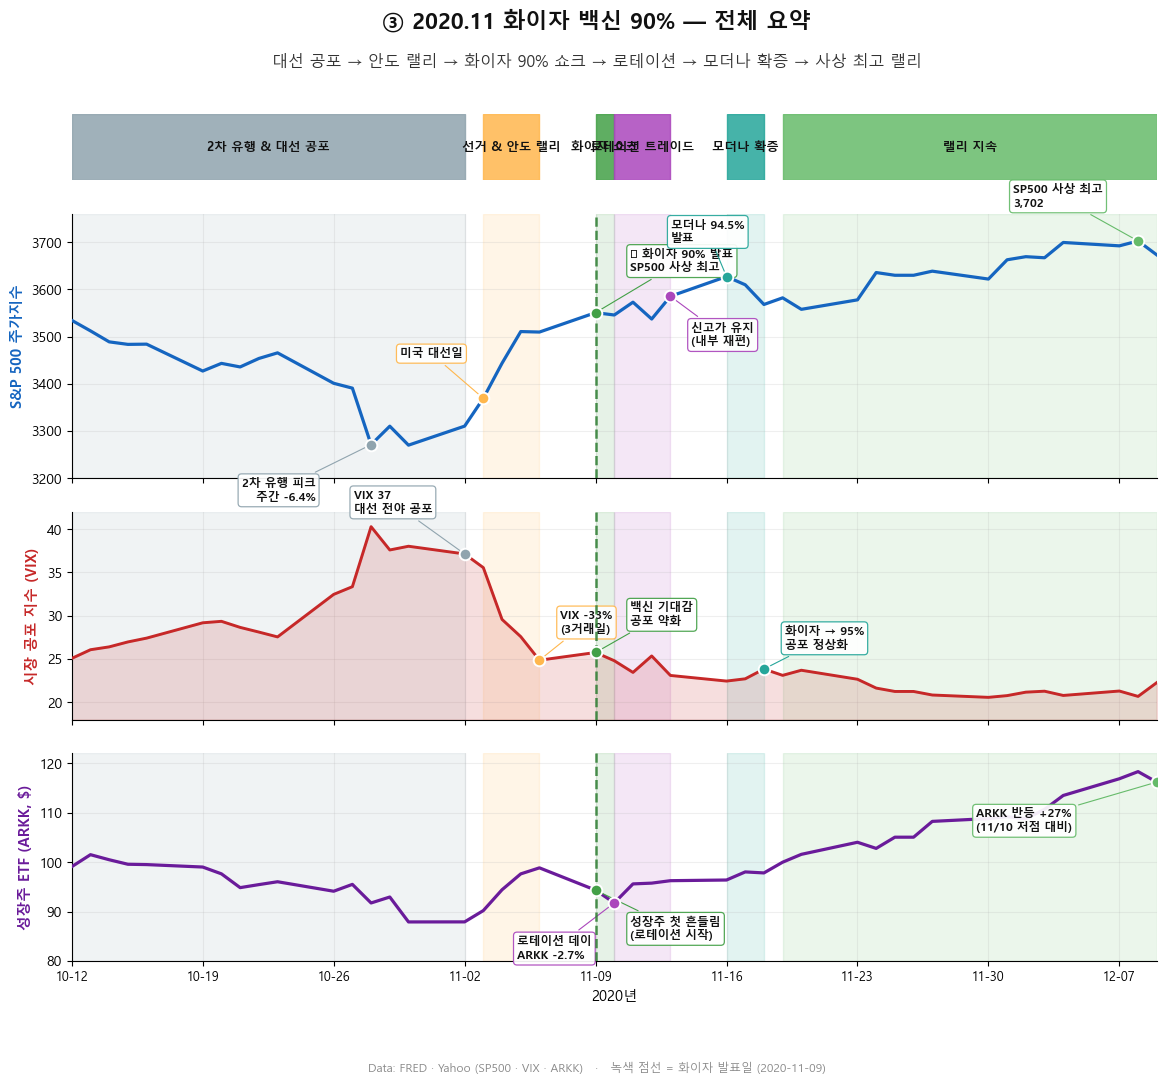


[OK] 종합 프레임: c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e03_story\99_summary.png


In [6]:
def draw_summary():
    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.35, 1.4, 1.1, 1.1], hspace=0.18)
    ax_rib  = fig.add_subplot(gs[0])
    ax_sp   = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_vix  = fig.add_subplot(gs[2], sharex=ax_rib)
    ax_arkk = fig.add_subplot(gs[3], sharex=ax_rib)

    # Ribbon
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='#111')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u2462 2020.11 화이자 백신 90% — 전체 요약',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935,
             '대선 공포 → 안도 랠리 → 화이자 90% 쇼크 → 로테이션 → 모더나 확증 → 사상 최고 랠리',
             ha='center', va='top', fontsize=11.5, color='#333', style='italic')

    # 국면별 배경 음영
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        for ax in (ax_sp, ax_vix, ax_arkk):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)

    ax_sp.plot(df.index, df['SP500'], color='#1565C0', lw=2.3, zorder=3)
    ax_vix.plot(df.index, df['VIX'], color='#C62828', lw=2.1, zorder=3)
    ax_vix.fill_between(df.index, df['VIX'], YLIM_VIX[0], color='#C62828', alpha=0.15, zorder=2)
    ax_arkk.plot(df.index, df['ARKK'], color='#6A1B9A', lw=2.3, zorder=3)

    ax_sp.set_ylabel(LABELS['SP500'], fontsize=10.5, fontweight='bold', color='#1565C0')
    ax_vix.set_ylabel(LABELS['VIX'], fontsize=10.5, fontweight='bold', color='#C62828')
    ax_arkk.set_ylabel(LABELS['ARKK'], fontsize=10.5, fontweight='bold', color='#6A1B9A')

    for ax in (ax_sp, ax_vix, ax_arkk):
        ax.grid(alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_sp.set_ylim(YLIM_SP)
    ax_vix.set_ylim(YLIM_VIX)
    ax_arkk.set_ylim(YLIM_ARKK)

    # 변곡점 강조
    pfizer = pd.Timestamp('2020-11-09')
    for ax in (ax_sp, ax_vix, ax_arkk):
        ax.axvline(pfizer, color='#2E7D32', linestyle='--', lw=1.8, alpha=0.85, zorder=4)

    # 모든 hero annotations
    axmap = {'SP500': ax_sp, 'VIX': ax_vix, 'ARKK': ax_arkk}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date)
            c = phase['color']
            ax.scatter([d], [y], s=70, color=c, zorder=6,
                       edgecolors='white', lw=1.4)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8.5,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                                  ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    ax_arkk.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_arkk.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_arkk.tick_params(axis='x', labelsize=9)
    ax_arkk.set_xlabel('2020년', fontsize=10.5)
    for ax in (ax_rib, ax_sp, ax_vix):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: FRED · Yahoo (SP500 · VIX · ARKK)   ·   녹색 점선 = 화이자 발표일 (2020-11-09)',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out


fig, path = draw_summary()
plt.show()
print(f'\n[OK] 종합 프레임: {path}')

## 7. 최종 산출물 목록

In [ ]:
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(ROOT)}   ({f.stat().st_size // 1024} KB)')